In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [35]:
data = sns.load_dataset("penguins")

In [36]:
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [37]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [38]:
data.dropna(inplace = True)

In [39]:
data.reset_index(drop=True, inplace=True)

In [40]:
numeric_vars = ["body_mass_g", "bill_length_mm", "bill_depth_mm", "flipper_length_mm"]

In [41]:
all_vars = numeric_vars + ["species"]

In [42]:
p = len(all_vars)

In [43]:
data[numeric_vars].mean()

body_mass_g          4207.057057
bill_length_mm         43.992793
bill_depth_mm          17.164865
flipper_length_mm     200.966967
dtype: float64

In [44]:
np.cov(data[numeric_vars], rowvar = False)

array([[ 6.48372488e+05,  2.59562330e+03, -7.48456122e+02,
         9.85219165e+03],
       [ 2.59562330e+03,  2.99063334e+01, -2.46209134e+00,
         5.00581949e+01],
       [-7.48456122e+02, -2.46209134e+00,  3.87788831e+00,
        -1.59472485e+01],
       [ 9.85219165e+03,  5.00581949e+01, -1.59472485e+01,
         1.96441677e+02]])

In [45]:
data.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [46]:
species_order = ["Adelie", "Chinstrap", "Gentoo"]

In [47]:
palette = {"Adelie": "#F4A825",
           "Chinstrap": "#A569BD",
           "Gentoo": "#1B9E88"}

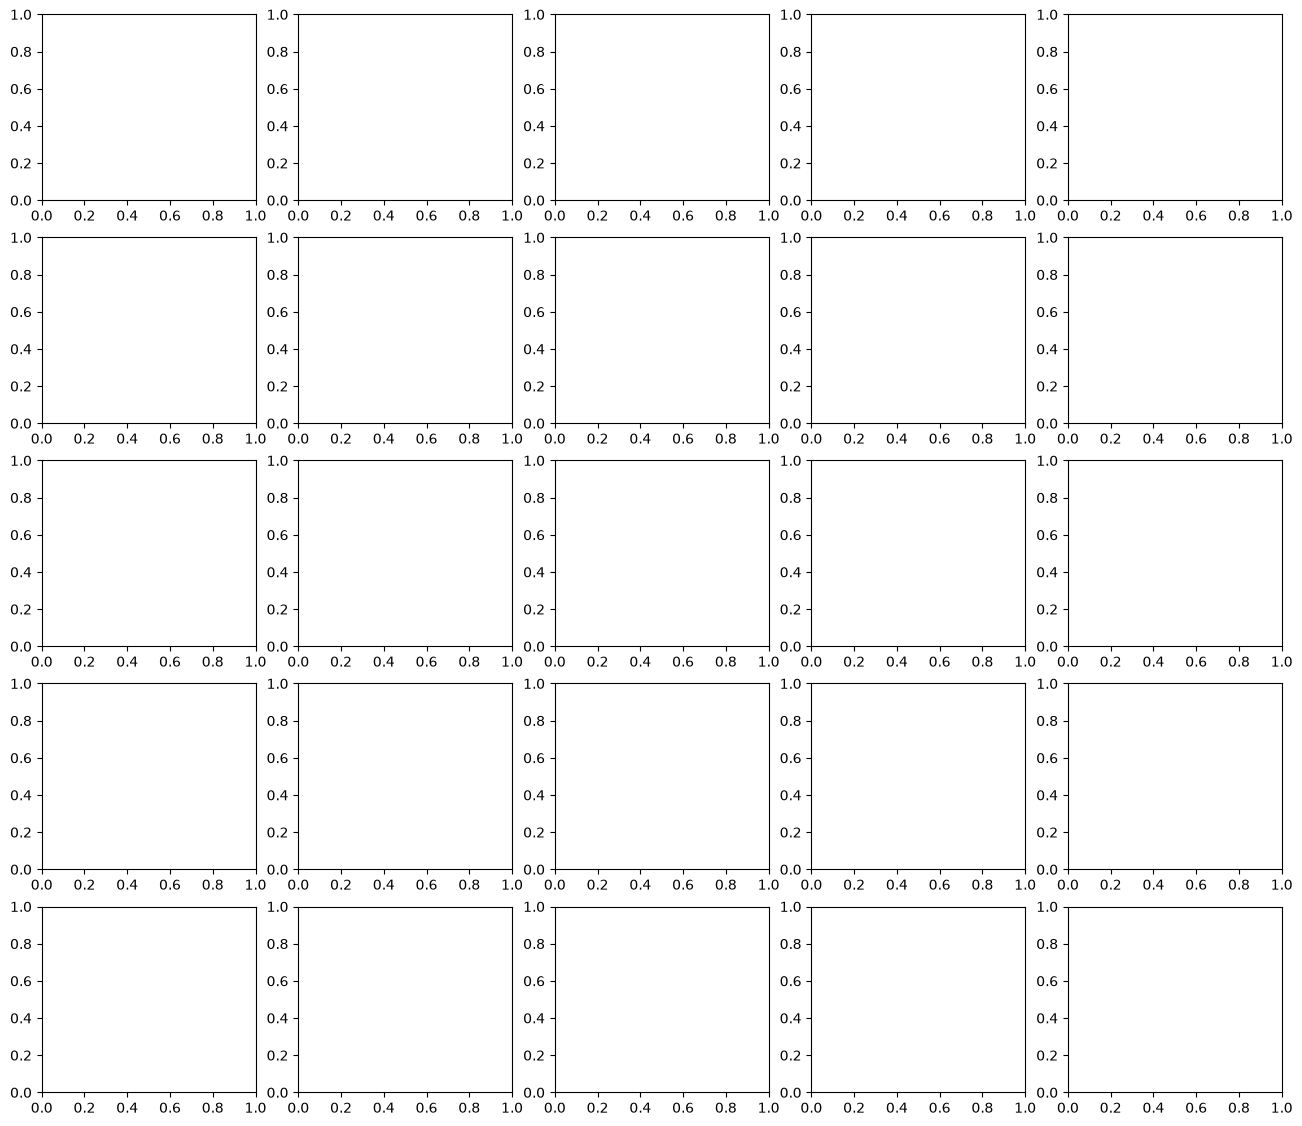

In [48]:
fig, axes = plt.subplots(p, p, figsize = (16, 14))

In [49]:
counts = data["species"].value_counts().reset_index()

<Axes: ylabel='count'>

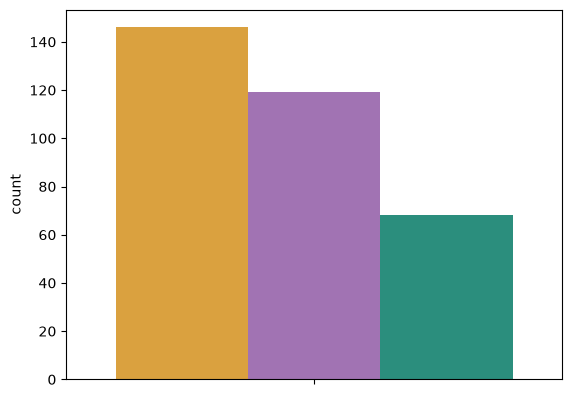

In [50]:
sns.barplot(data = counts,
            hue = "species",
            y = "count",
            palette = ["#F4A825",
                       "#A569BD",
                       "#1B9E88"],
            legend = False)

In [51]:
sns.barplot(data = counts,
            hue = "species",
            y = "count",
            palette = ["#F4A825",
                       "#A569BD",
                       "#1B9E88"],
            legend = False,
            ax = axes[0, 0])
axes[0, 0].set_xticklabels([])
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

Text(4.444444444444452, 0.5, '')

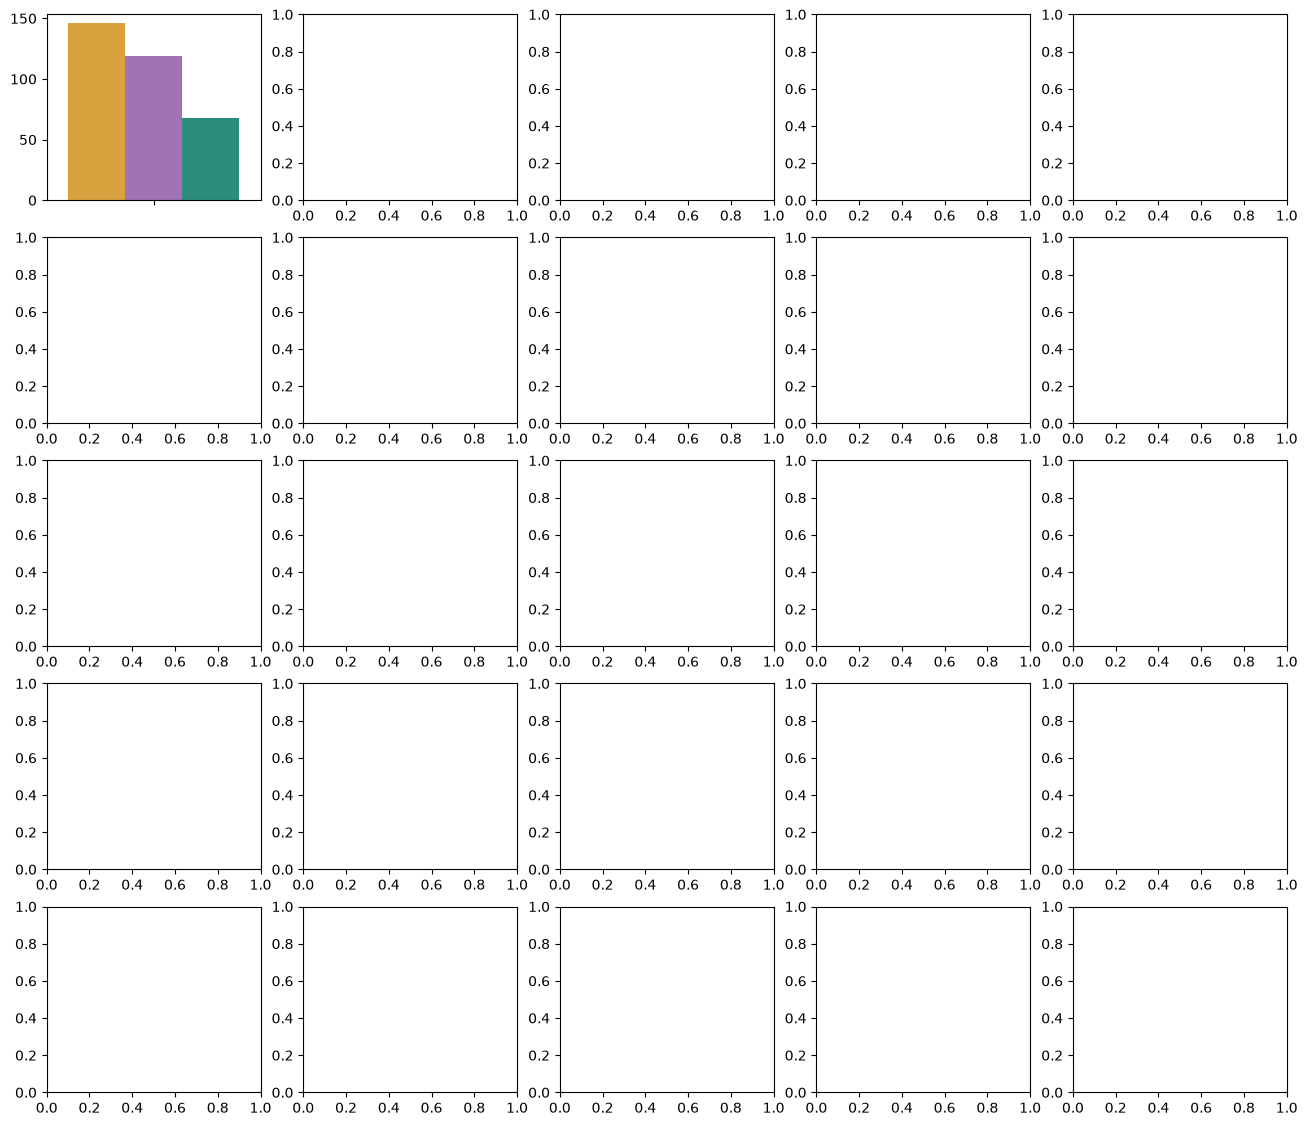

In [52]:
fig

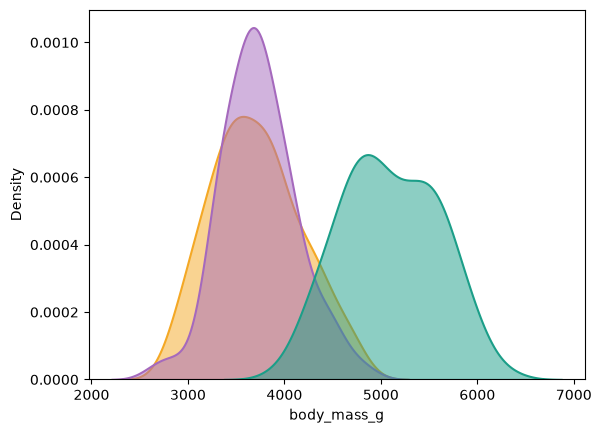

In [53]:
for sp in species_order:
    ## Filtramos los datos por especie
    subset = data.loc[data["species"] == sp, numeric_vars[0]]

    ## Realizamos el kernel plot
    sns.kdeplot(data = subset,
                fill = True,
                color = palette[sp],
                alpha = 0.50,
                linewidth = 1.5)

In [54]:
for i, var in enumerate(numeric_vars):
    for sp in species_order:
        ## Filtramos los datos por especie
        subset = data.loc[data["species"] == sp, var]

        ## Creamos el kernel plot y lo
        ## ubicamos en la diagonal
        sns.kdeplot(data = subset,
                    fill = True,
                    color = palette[sp],
                    alpha = 0.50,
                    linewidth = 1.5,
                    ax = axes[i + 1, i + 1])

        ## Eliminamos los nombres de los ejes
        axes[i + 1, i + 1].set_ylabel("")
        axes[i + 1, i + 1].set_xlabel("")

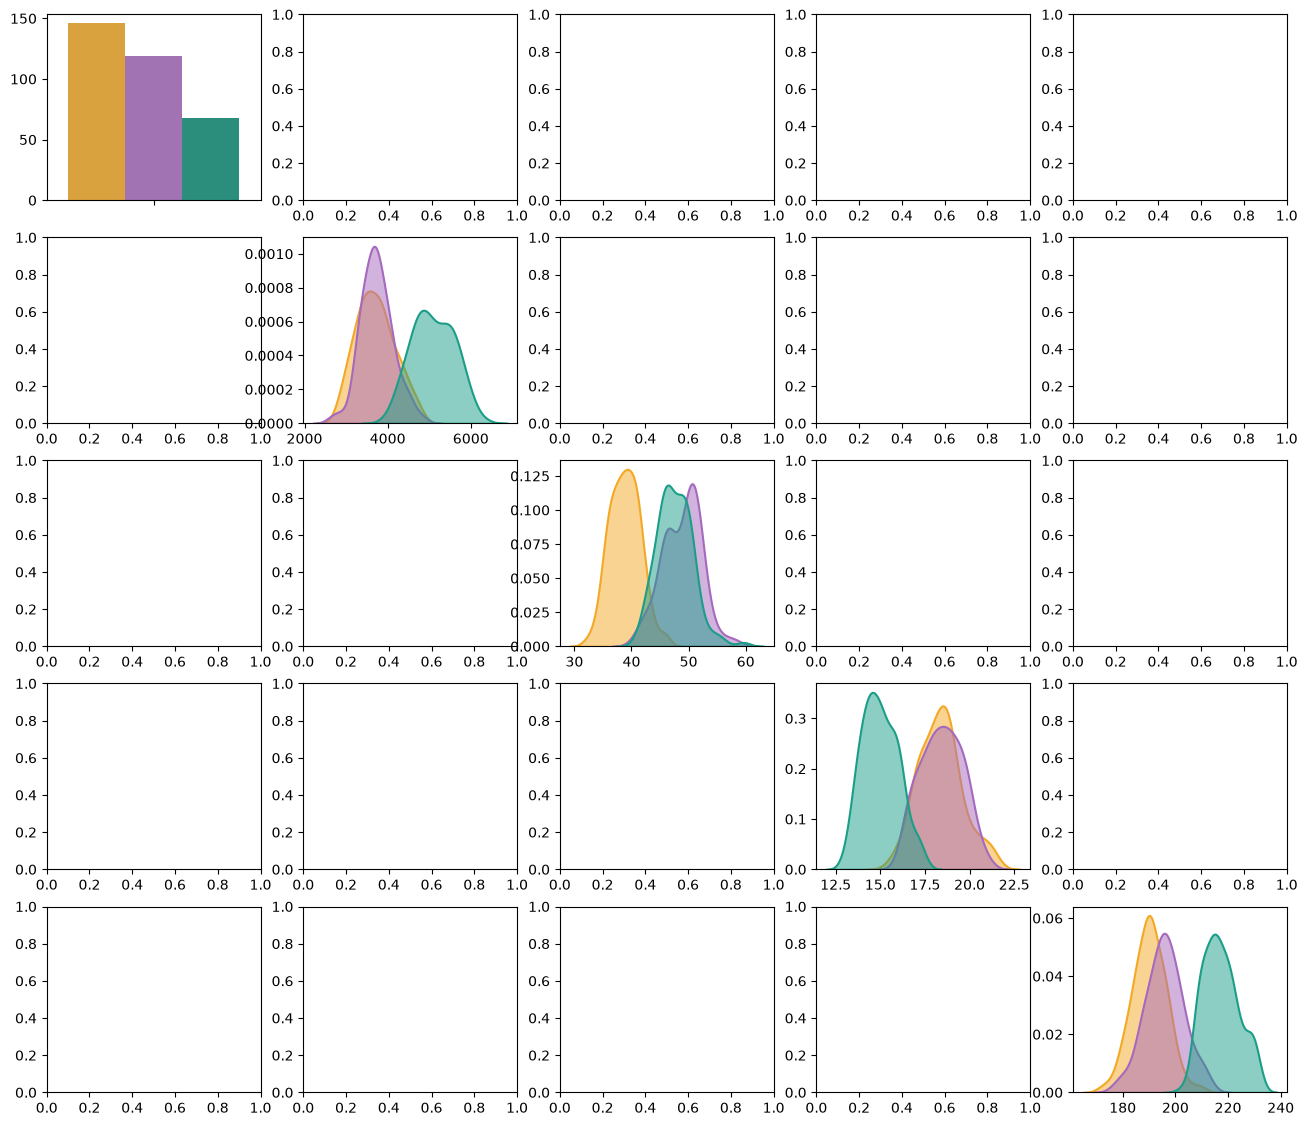

In [55]:
fig

In [56]:
for i, var in enumerate(numeric_vars):
    ## Definimos las posiciones
    ax = axes[0, i+1]

    ## Creamos el box plot por
    ## variable dividido por especie
    sns.boxplot(data = data,
                x = var,
                y = "species",
                hue = "species",
                palette = palette,
                order = species_order,
                hue_order = species_order,
                legend = False,
                ax = ax)

    ## Removemos nombres de ejes y marcas
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticklabels([])

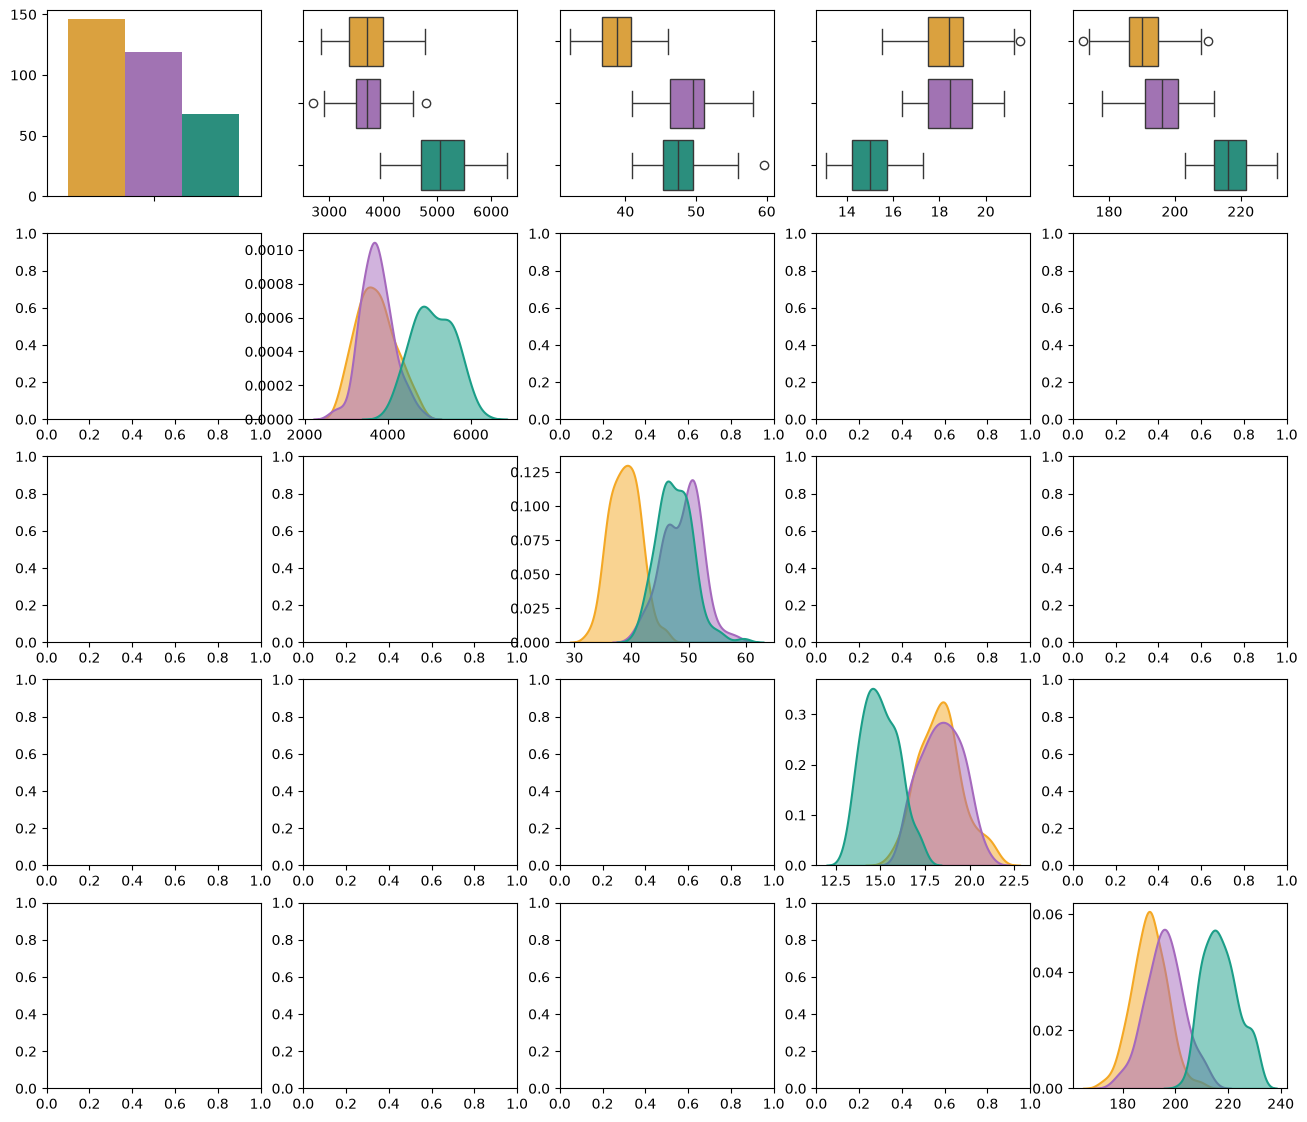

In [57]:
fig

In [58]:
for i, var in enumerate(numeric_vars):
    ## Definimos la posición y limpiamos
    ## el eje principal para reemplazarlo
    ## con 3 (número de especies) sub-ejes
    ax = axes[i+1, 0]
    ax.axis("off")

    for j, sp in enumerate(species_order):
        ## Creamos los sub-ejes
        ## [left, bottom, width, height]
        sub_ax = ax.inset_axes([0,
                                1 - (j + 1) * (1/len(species_order)),
                                1,
                                1/len(species_order) - 0.05])
            
        ## Filtramos los datos
        subset = data[data["species"] == sp]

        ## Para cada especie posicionamos el
        ## histograma correspondiente en el
        ## sub-eje que le corresponda
        sns.histplot(data = subset,
                     x = var,
                     color = palette[sp],
                     bins = 12,
                     ax = sub_ax)

        ## Removemos nombres de los ejes
        sub_ax.set_ylabel("")
        sub_ax.set_xlabel("")

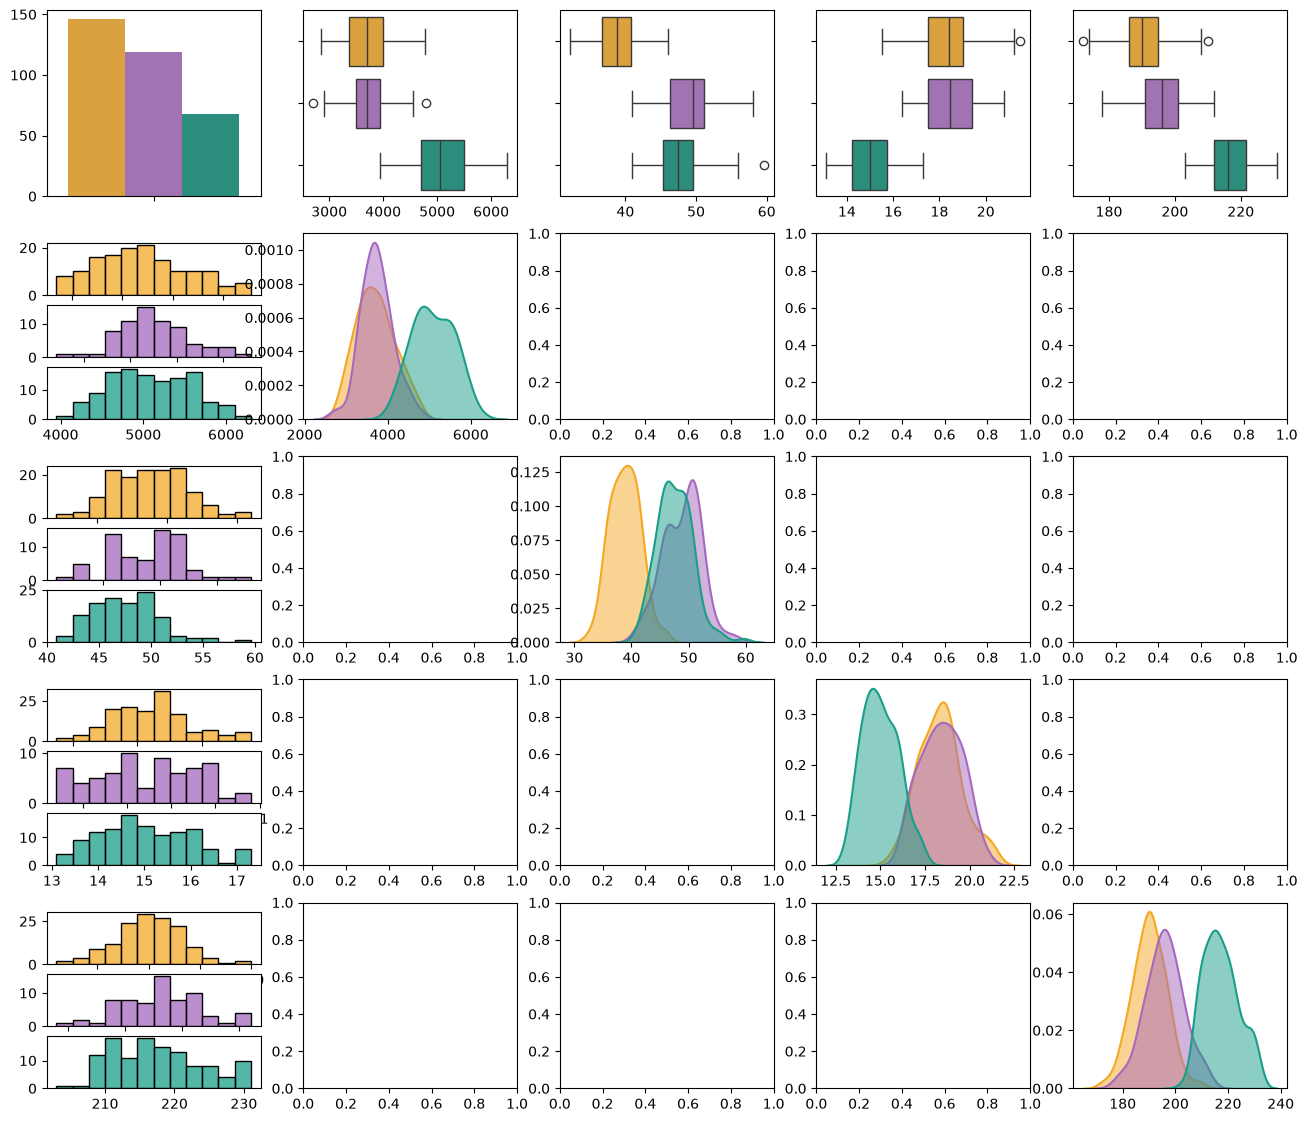

In [59]:
fig

In [60]:
for j in range(len(numeric_vars) - 1):
    for i in range(j + 1, len(numeric_vars)):
        ## Definimos la posición
        ax = axes[i + 1, j + 1]

        ## Creamos los scatter plots
        sns.scatterplot(data = data,
                        x = numeric_vars[i],
                        y = numeric_vars[j],
                        hue = "species",
                        palette = palette,
                        legend = False,
                        s = 25,
                        alpha = 0.70,
                        hue_order = species_order,
                        ax = ax)

        ## Removemos los nombres de los ejes
        ax.set_xlabel("")
        ax.set_ylabel("")

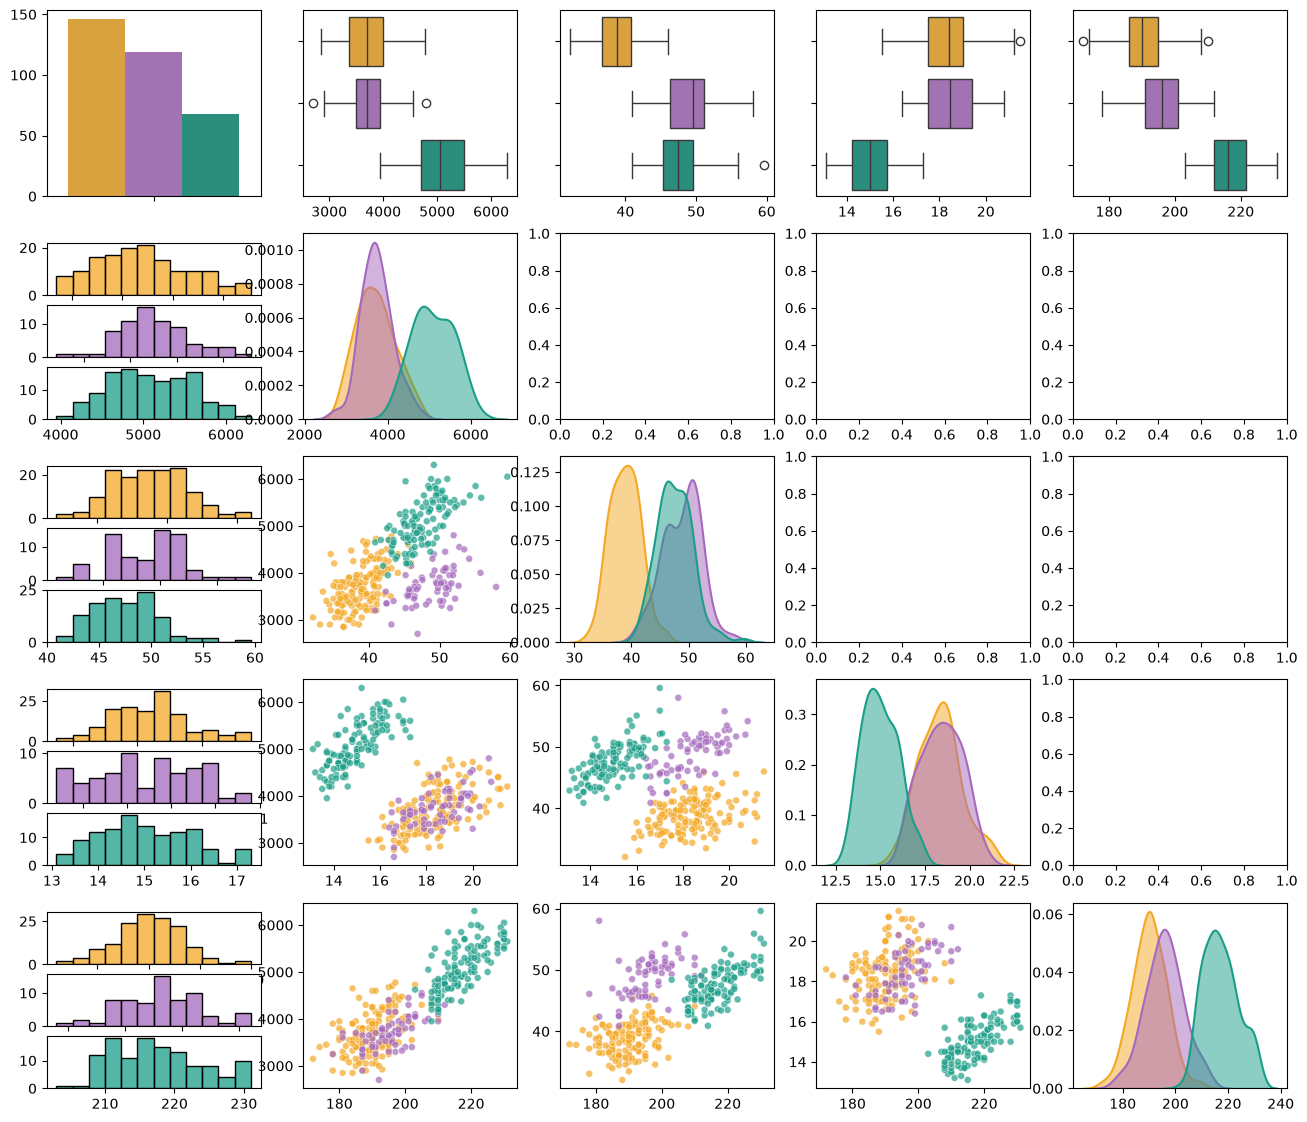

In [61]:
fig

In [62]:
def corr_stars(x: np.array, y: np.array):
    '''
    Calcula la correlación de Pearson y
    devuelve una clasificación de su significancia
    basada en la nomenclatura de R

    Argumentos
    ----------
    x: np.array
        Arreglo con las observaciones de una variable
    y: np.array
        Arreglo con las observaciones de una segunda variable

    Output
    ------
    r: np.float
        Coeficiente de correlación
    s: str
        Significancia del p-value
    '''

    ## Calcula la correlación
    r, p = stats.pearsonr(x, y)

    ## Clasifica la significancia
    ## dependiendo del p-value
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = ""

    return r, stars

In [63]:
for i in range(len(numeric_vars) - 1):
    for j in range(i + 1, len(numeric_vars)):
        ## Definimos la posición
        ax = axes[i + 1, j + 1]

        ## Calculamos la correlación
        ## incluyendo todas las observaciones
        r_all, s_all = corr_stars(data[numeric_vars[i]],
                                  data[numeric_vars[j]])

        ## Llevamos una lista con los
        ## resultados para imprimir en
        ## el espacio correspondiente
        cor_text = [f"Corr: {r_all:.4f}{s_all}"]

        for sp in species_order:
            ## Filtramos por especie
            subset = data[data["species"] == sp]

            ## Calculamos la correlación solo
            ## con las observaciones de cada especie
            r_sp, s_sp = corr_stars(subset[numeric_vars[i]],
                                    subset[numeric_vars[j]])

            ## Añadimos el resultado a la lista
            cor_text.append(f"{sp}: {r_sp:.4f}{s_sp}")

        ## En la posición correspondiente
        ## colocamos el texto de la lista
        ## incluyendo un salto de línea entre
        ## cada uno de los cálculos realizados
        ax.text(0.5, 0.5,
                "\n".join(cor_text),
                ha = "center",
                va = "center",
                fontsize = 14)

        ## Removemos marcas de ambos ejes
        ax.set_xticks([])
        ax.set_yticks([])

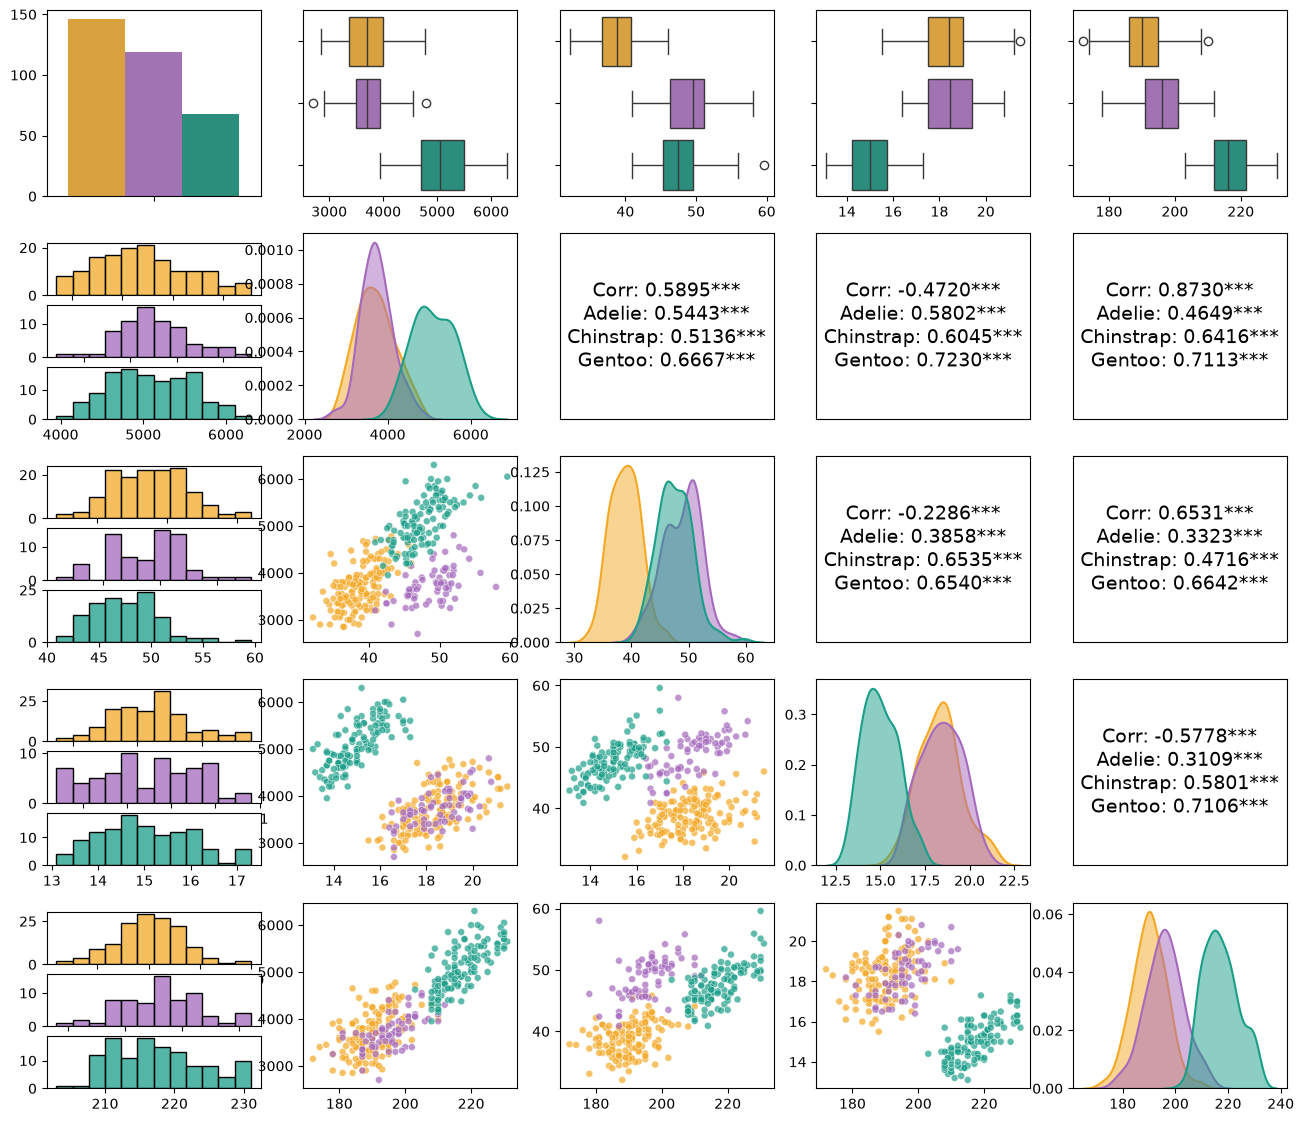

In [64]:
fig

In [65]:
for i, row_var in enumerate(all_vars):
    for j, col_var in enumerate(all_vars):
        ## Define la posición
        ax = axes[i, j]

        ## Quita marcas del eje x
        if i != p - 1:
            ax.set_xticklabels([])

        ## Coloca nombres de variables
        ## en la parte superior
        if i == 0:
            ax.set_title(col_var,
                         fontsize = 14,
                         fontweight = "bold")

        ## Coloca nombres de variables
        ## en el extremo derecho
        if j == p - 1:
            ax.yaxis.set_label_position("right")
            ax.set_ylabel(row_var,
                          fontsize = 14,
                          rotation = 270,
                          labelpad = 20,
                          fontweight = "bold")
fig.tight_layout()

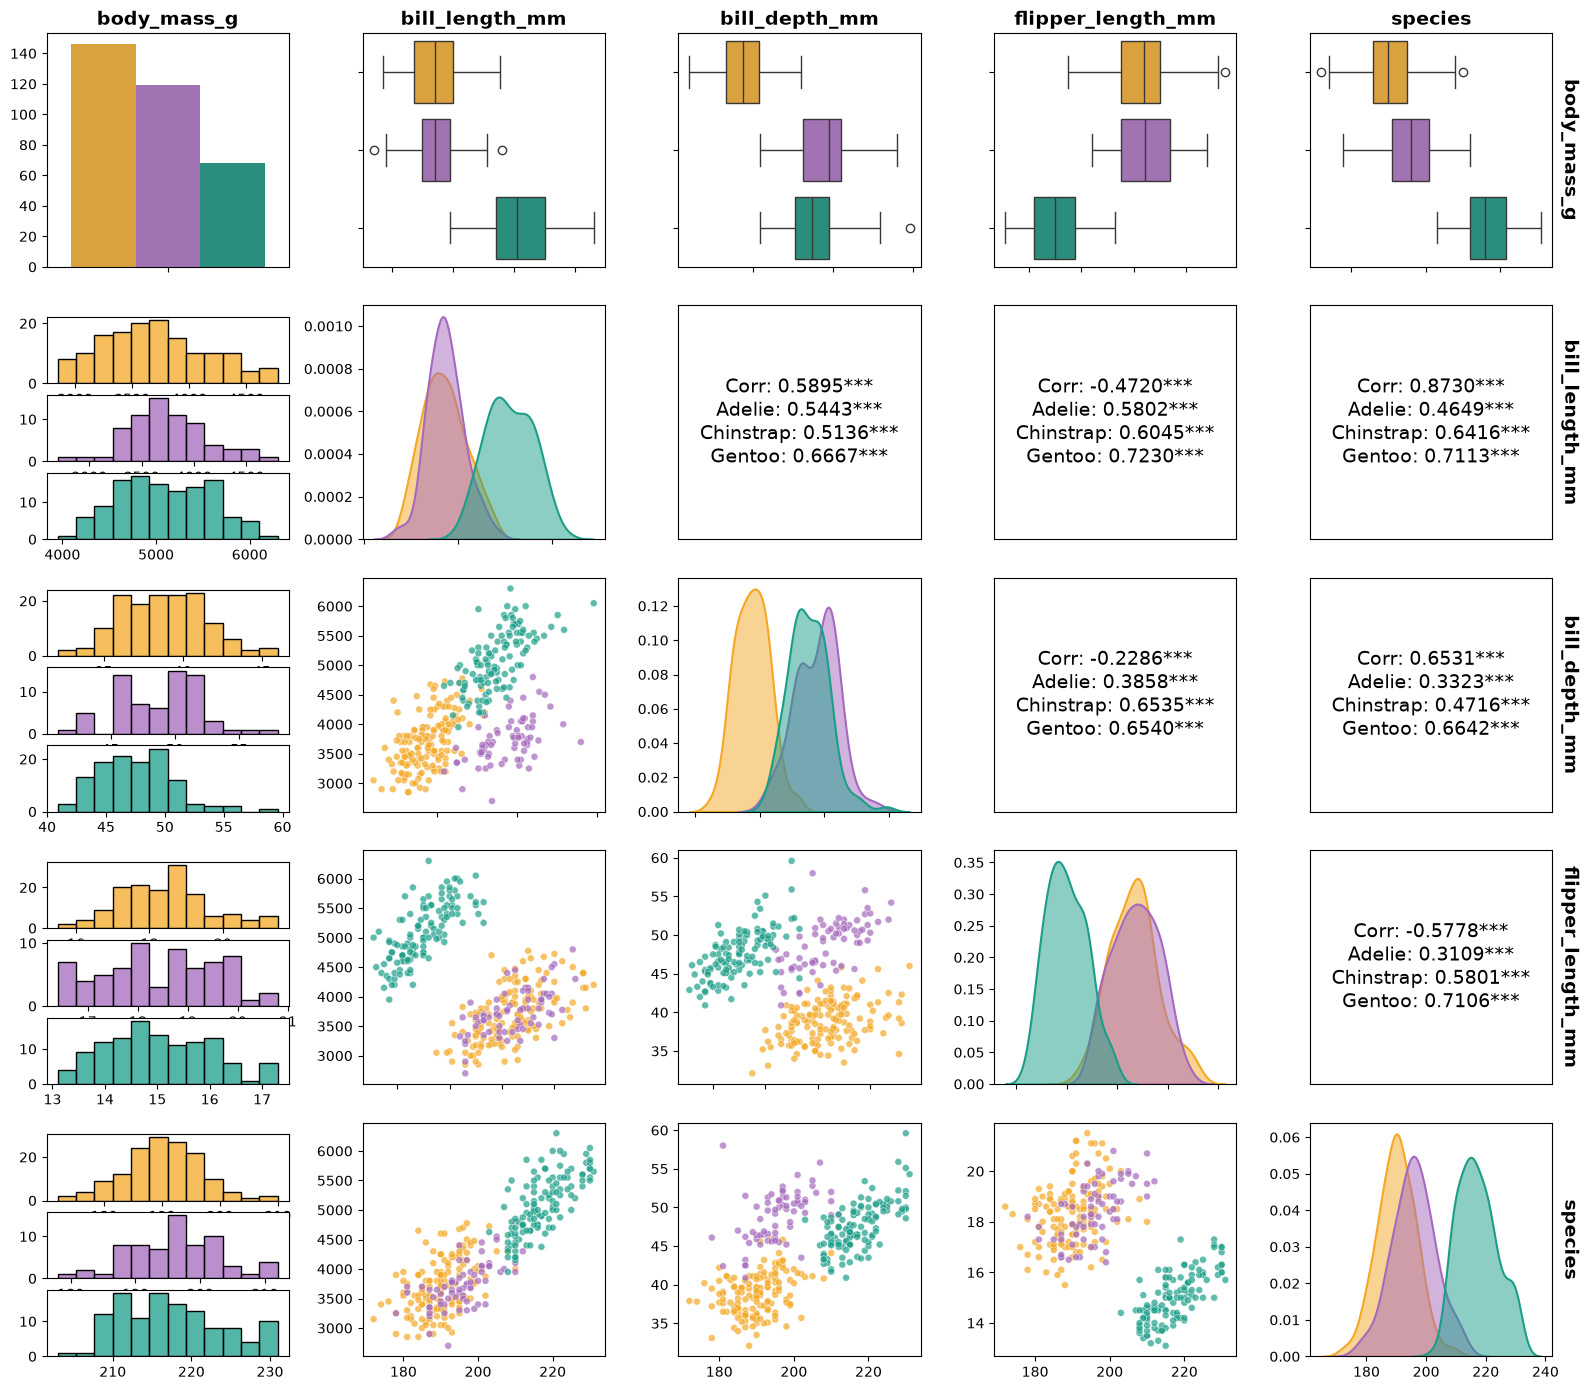

In [66]:
fig